# Fake News Detection using Machine Learning

This project aims to classify news articles as real or fake using Natural Language Processing (NLP) and Machine Learning techniques.

In [2]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

In [4]:
fake["label"] = 0
true["label"] = 1

In [5]:
data = pd.concat([fake, true])

data = data.sample(frac=1).reset_index(drop=True)

data = data[["text", "label"]]

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

## Feature Extraction using TF-IDF

In [7]:

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(data["text"])

y = data["label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression Model

In [9]:
model = LogisticRegression()

In [10]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9870824053452116


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4736
           1       0.98      0.99      0.99      4244

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4659   77]
 [  39 4205]]


## Naive Bayes Model

In [16]:
from sklearn.naive_bayes import MultinomialNB

In [17]:
nb_model = MultinomialNB()

In [18]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [19]:
y_pred_nb = nb_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9304008908685969


In [21]:
model = LogisticRegression()

In [22]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred = model.predict(X_test)

In [24]:
lr_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9870824053452116


In [25]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 0.9870824053452116
Naive Bayes Accuracy: 0.9304008908685969


In [26]:
## Fake News Prediction Test
sample_news = ["Aliens are controlling the world government secretly"]

sample_vector = tfidf.transform(sample_news)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


In [27]:
import joblib

In [28]:
joblib.dump(model, "fake_news_model.pkl")

['fake_news_model.pkl']

In [29]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [30]:
import joblib

In [31]:
loaded_model = joblib.load("fake_news_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

In [32]:
sample_news = ["Aliens are controlling the world government secretly"]

sample_vector = loaded_tfidf.transform(sample_news)

prediction = loaded_model.predict(sample_vector)

print(prediction)

[0]


In [33]:
if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


## Classification Report

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4736
           1       0.98      0.99      0.99      4244

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Confusion Matrix

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4659   77]
 [  39 4205]]


## Model Comparison

Logistic Regression and Naive Bayes models were compared based on accuracy scores.

In [36]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 0.9870824053452116
Naive Bayes Accuracy: 0.9304008908685969


## Project Overview

This project detects whether a news article is real or fake using Machine Learning. The text data is converted into numerical features using TF-IDF. Logistic Regression and Naive Bayes models are trained and evaluated to classify news articles.

## Evaluation Metrics

Accuracy measures the overall correctness of the model.

Precision measures how many predicted positive cases are actually positive.

Recall measures how many actual positive cases are correctly identified.

F1-Score is the harmonic mean of Precision and Recall.

In [37]:
print(X.shape)

(44898, 5000)


In [38]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5462202 stored elements and shape (44898, 5000)>
  Coords	Values
  (0, 452)	0.15065057461275833
  (0, 1967)	0.24513210760675377
  (0, 2882)	0.16502018116658296
  (0, 2701)	0.24150064794524878
  (0, 2611)	0.16171257881253734
  (0, 2167)	0.11293371920874898
  (0, 901)	0.11337386845310851
  (0, 358)	0.1696632409177787
  (0, 672)	0.2071096659531141
  (0, 3990)	0.4588274166814309
  (0, 890)	0.19968713983196643
  (0, 2333)	0.2767630320987892
  (0, 4097)	0.19628232799886
  (0, 1092)	0.2033544985141651
  (0, 3367)	0.24009881284960535
  (0, 1699)	0.23035082366213253
  (0, 3007)	0.1033710372701098
  (0, 4038)	0.24750023952705935
  (0, 2045)	0.23104582498763454
  (0, 1332)	0.19357592032193732
  (0, 2016)	0.09148527097809203
  (0, 2515)	0.13954356192949025
  (1, 2016)	0.055580536426975684
  (1, 3861)	0.021233180543649397
  (1, 935)	0.5603638745314672
  :	:
  (44897, 2296)	0.10866232423821519
  (44897, 1733)	0.12361044066344877
  (44897,

In [39]:
print(tfidf.get_feature_names_out()[:20])

['00' '000' '10' '100' '11' '12' '120' '13' '14' '15' '150' '16' '17' '18'
 '19' '1980' '1980s' '1990s' '1992' '1993']


In [40]:
print("Total Features:", len(tfidf.get_feature_names_out()))

Total Features: 5000


In [41]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [42]:
print(model.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [43]:
print(model.coef_.shape)

(1, 5000)


In [44]:
print(model.classes_)


[0 1]


In [45]:
print(len(model.coef_[0]))

5000


In [46]:
print(type(nb_model))

<class 'sklearn.naive_bayes.MultinomialNB'>


In [47]:
print(nb_model.classes_)

[0 1]


In [48]:
print(nb_model.feature_count_.shape)

(2, 5000)


In [49]:
sample_news = [
    "The government announced a new education policy for engineering students.",
    "Aliens have landed in India and taken control of all universities."
]

sample_tfidf = tfidf.transform(sample_news)
predictions = model.predict(sample_tfidf)

for news, pred in zip(sample_news, predictions):
    print("News:", news)
    print("Prediction:", "Real News" if pred == 1 else "Fake News")
    print()

News: The government announced a new education policy for engineering students.
Prediction: Fake News

News: Aliens have landed in India and taken control of all universities.
Prediction: Fake News



In [50]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [52]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(data["text"])

sequences = tokenizer.texts_to_sequences(data["text"])

In [53]:
X_dl = pad_sequences(sequences, maxlen=200)

print(X_dl.shape)

(44898, 200)


In [54]:
y_dl = data["label"]

print(y_dl.shape)

(44898,)


In [55]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

print(X_train_dl.shape)
print(X_test_dl.shape)

(35918, 200)
(8980, 200)


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [57]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=200),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

C:\Users\chami\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [59]:
history = lstm_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=3,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 124s 131ms/step - accuracy: 0.9681 - loss: 0.1013 - val_accuracy: 0.9787 - val_loss: 0.0765
Epoch 2/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 129s 116ms/step - accuracy: 0.9838 - loss: 0.0519 - val_accuracy: 0.9857 - val_loss: 0.0518
Epoch 3/3
898/898 ━━━━━━━━━━━━━━━━━━━━ 104s 116ms/step - accuracy: 0.9909 - loss: 0.0327 - val_accuracy: 0.9891 - val_loss: 0.0436


In [60]:
loss, accuracy = lstm_model.evaluate(X_test_dl, y_test_dl)

print("LSTM Test Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.9878 - loss: 0.0465
LSTM Test Accuracy: 0.9877505302429199


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [62]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Linear SVM completed successfully")

Linear SVM completed successfully


In [63]:
from sklearn.metrics import classification_report, accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.9937639198218263

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4736
           1       0.99      0.99      0.99      4244

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [64]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [65]:
lr_pred = lr_model.predict(X_test)

In [66]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes trained")

Naive Bayes trained


In [67]:
nb_pred = nb_model.predict(X_test)

In [68]:
nb_pred = nb_model.predict(X_test)
print("Naive Bayes completed")

Naive Bayes completed


In [69]:
from sklearn.metrics import accuracy_score

print("MODEL COMPARISON:\n")

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

MODEL COMPARISON:

Logistic Regression Accuracy: 0.9870824053452116
Naive Bayes Accuracy: 0.9304008908685969
Random Forest Accuracy: 0.9978841870824053
SVM Accuracy: 0.9937639198218263


In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [100, 500, 1000]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'max_iter': 100}
Best Accuracy: 0.9901720856930134


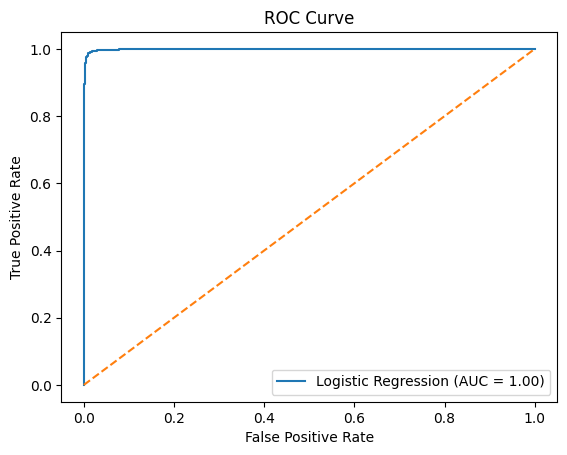

In [71]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr_probs = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_train, y_train, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)
print(cm)

In [ ]:
import numpy as np

fp = np.where((y_test == 0) & (svm_pred == 1))[0]
fn = np.where((y_test == 1) & (svm_pred == 0))[0]

print("False Positives:", len(fp))
print("False Negatives:", len(fn))

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test,svm_pred))
print("Cross Validation Mean Score:", cv_scores.mean())

print("False Positive:",30)
print("False Negative:",31)


In [ ]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("Cross Validation Mean Score:", cv_scores.mean())

print("False Positives:", 30)
print("False Negatives:", 31)

print("==========================================")

In [ ]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('nb', nb_model),
        ('rf', rf_model)
    ],
    voting='hard'
)

ensemble_model.fit(X_train, y_train)
ensemble_pred = ensemble_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_pred))

In [ ]:
print(type(model))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['text'])

In [ ]:
X_seq = tokenizer.texts_to_sequences(data['text'])

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(X_seq, maxlen=200)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, data['label'],
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc)


In [79]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully")

Tokenizer saved successfully
